<div style="font-family:courier; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h1 align="left"><font color='#000000'>SDSC2001 Tutorial 11: Machine Learning</font></h1>

TA: Nicole

Email: nicole.xu@my.cityu.edu.hk

<p style="font-family: courier; 
          font-weight: bold; 
          letter-spacing: 0px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #bfe4f5" >Documentation</p>
          
Logistic regression: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html

Support vector machine: https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html

Random forest classifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

<p style="font-family: courier; 
          font-weight: bold; 
          letter-spacing: 0px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #bfe4f5" >Tutorial Summary</p>

This tutorial will perform prediction tasks on a breast cancer dataset. We will use logistic regression, random forest, and support vector machine, subsequently compare the model performance. Before we begin, make sure the data and the Jupyter notebook are in the same folder on your local computer.



In [3]:
# import neccesary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Test train split
from sklearn.model_selection import train_test_split 

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evaluation metrics
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_curve, auc

# Random forest classifier
from sklearn.ensemble import RandomForestClassifier
# Support vector machine (classifier)
from sklearn.svm import SVC
# Logistic regression 
from sklearn.linear_model import LogisticRegression

<p style="font-family: courier; 
          font-weight: bold; 
          letter-spacing: 0px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #bfe4f5" >Code Reference</p>
          
If you get stuck on any of the problems in this tutorial please reference the table below.
          
 

| Operations | Code | Notes |
| :--- | :--- | :--- | 
|Dropping a column from a data set (Pandas)|```df.drop('colname', axis=1)```|
|Selecting a single column (Pandas)|```df.loc[:,'colname']```|
|Splitting your data|```X_train, X_test, y_train, y_test``` <br><br> ```= train_test_split(X, y, random_state = 42)```|Where ```X``` is your feature matrix and ```y``` is your target.|
|Creating a logistic regression|```lr = LogisticRegression(random_state = 0)```|
|Creating a random forest (classifier) |```rf = RandomForestClassifier(random_state = 0)```|
|Creating a support vector machine classifier|```svm = SVC(random_state = 0)```|
|Fitting (training) a model|```model_name.fit(X = X_train, y = y_train)```|For the random forest model defined above we would use ```rf.fit()``` |
|Making predictions|```model_name.predict(X = X_test)```|Often we need to save our predictions, ie ```model_preds = ....```|
|Getting the accuracy of our model|```accuracy_score(y_true = target, y_pred = model_preds)```|

<p style="font-family: courier; 
          font-weight: bold; 
          letter-spacing: 0px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #bfe4f5" >Data and simple preprocessing</p>

        
          
 

In [4]:
df = pd.read_csv('./data_breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

In [6]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [8]:
df['diagnosis'].value_counts(dropna=0)

diagnosis
0    357
1    212
Name: count, dtype: int64

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(1) Features, label and data splitting</font></h3>
   
a. Defines 'diagnosis' as y, which will be the label.

b. Defines X as all other columns in the data, which will be the features
    
c. Split the data into training and testing sets. Use `random_state = 42` so that we all get the same results.    


In [5]:
# Write your code below
y = df.loc[:, "diagnosis"]
X = df.drop("diagnosis", axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 30) (114, 30) (455,) (114,)


<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(2) Defining and Fitting (Training) Models</font></h3>

Write code below that defines and fits (trains) the following models on the training data:
    
    1. Logistic regression, name the model lr
    2. Support vector machine, name the model svm
    3. Random forest, name the model rf

Note: please use random_state = 0 for all models so we all get the same results.

In [7]:
# Write your code for the logistic regression
lr = LogisticRegression(max_iter=100, random_state=0)
lr.fit(X_train, y_train)

# Write your code for the random forest
rf = RandomForestClassifier(n_estimators = 100, max_depth=9, min_samples_leaf=2, random_state = 0)
rf.fit(X_train, y_train)

# Write your code for the support vector machine
svm = SVC(kernel='rbf', probability=True, random_state = 0)
svm.fit(X_train, y_train)

/Users/apple/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SVC(probability=True, random_state=0)

<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(3) Making predictions</font></h3>

Write code below that obtains predictions on the training and testing sets for both models. Print the accuracy for both models for all the training and testing set predictions


In [8]:
# Write your code below

# logistic regression
# Predict on the training and testing sets
lr_train_preds = lr.predict(X_train)
lr_test_preds = lr.predict(X_test)

# Calculate and print accuracy 
print("The accuracy of the lr model on the training set is:", accuracy_score(y_train, lr_train_preds))
print("The accuracy of the lr model on the testing set is:", accuracy_score(y_test, lr_test_preds))


# Random forest 
# Predict on the training and testing sets
rf_train_preds = rf.predict(X_train)
rf_test_preds = rf.predict(X_test)

# Calculate and print accuracy 
print("The accuracy of the rf model on the training set is:", accuracy_score(y_train, rf_train_preds))
print("The accuracy of the rf model on the testing set is:", accuracy_score(y_test, rf_test_preds))

# Support vector machine 
# Predict on the training and testing sets
svm_train_preds = svm.predict(X_train)
svm_test_preds = svm.predict(X_test)

# Calculate and print accuracy
print("The accuracy of the svm model on the training set is:", accuracy_score(y_train, svm_train_preds))
print("The accuracy of the svm model on the testing set is:", accuracy_score(y_test, svm_test_preds))


The accuracy of the lr model on the training set is: 0.9494505494505494
The accuracy of the lr model on the testing set is: 0.9210526315789473
The accuracy of the rf model on the training set is: 0.9934065934065934
The accuracy of the rf model on the testing set is: 0.956140350877193
The accuracy of the svm model on the training set is: 0.9186813186813186
The accuracy of the svm model on the testing set is: 0.9035087719298246


<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(4) Consider the Questions Below</font></h3>

a. If there is a large difference between the accuracy on the training set and the testing set for the random forest model, what is that an example of? 
    
Answer: **Overfitting**
    
b. What is one way we could try to fix the problem from part  
    
Answer: **Change the hyperparameters**
    


<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(5) Choosing the model evaluation metrics critically</font></h3>
    
a. What is one limitation that using accuracy to evaluate the model performance in our case?
    
Answer: **Imbalanced data**

In the context of breast cancer diagnosis, false negatives (predicting a malignant tumor as benign) are particularly concerning, as they may lead to delayed treatment and potentially serious consequences for the patient.
    
**Recall** (also known as sensitivity) measures the proportion of actual positive instances that are correctly predicted as positive. It answers the question, "Out of all the actual malignant instances, how many are correctly predicted as malignant?"

b. Print the recall for all models for both the training and testing set predictions

In [9]:
print("The recall of the LR model on the training set is:", recall_score(y_train, lr_train_preds))
print("The recall of the LR model on the testing set is:", recall_score(y_test, lr_test_preds))

print("The recall of the RF model on the training set is:", recall_score(y_train, rf_train_preds))
print("The recall of the RF model on the testing set is:", recall_score(y_test, rf_test_preds))

print("The recall of the SVM model on the training set is:", recall_score(y_train, svm_train_preds))
print("The recall of the SVM model on the testing set is:", recall_score(y_test, svm_test_preds))

The recall of the LR model on the training set is: 0.9117647058823529
The recall of the LR model on the testing set is: 0.8333333333333334
The recall of the RF model on the training set is: 0.9823529411764705
The recall of the RF model on the testing set is: 0.8809523809523809
The recall of the SVM model on the training set is: 0.8117647058823529
The recall of the SVM model on the testing set is: 0.7380952380952381


<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(6) Improving model performance</font></h3>
    
As our features have large differences in their distributions, scaling could be considered to ensure that all features contribute equally to the model and prevents features with larger values from dominating those with smaller values.
    
a. Use `StandardScaler` to scale the features.
    
b. Fit the model, make predictions on the training and testing set, and print the accuracy and recall for all models for both the training and testing set predictions


In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [11]:
# Fit models
lr = LogisticRegression(max_iter=100, random_state=0)
lr.fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators = 100, max_depth=9, min_samples_leaf=2, random_state = 0)
rf.fit(X_train, y_train)
svm = SVC(kernel='rbf', probability=True, random_state = 0)
svm.fit(X_train, y_train)


# Making predictions
lr_train_preds = lr.predict(X_train)
lr_test_preds = lr.predict(X_test)
rf_train_preds = rf.predict(X_train)
rf_test_preds = rf.predict(X_test)
svm_train_preds = svm.predict(X_train)
svm_test_preds = svm.predict(X_test)

# Accuracy
print("The accuracy of the lr model on the training set is:", accuracy_score(y_train, lr_train_preds))
print("The accuracy of the lr model on the testing set is:", accuracy_score(y_test, lr_test_preds))

print("The accuracy of the rf model on the training set is:", accuracy_score(y_train, rf_train_preds))
print("The accuracy of the rf model on the testing set is:", accuracy_score(y_test, rf_test_preds))

print("The accuracy of the svm model on the training set is:", accuracy_score(y_train, svm_train_preds))
print("The accuracy of the svm model on the testing set is:", accuracy_score(y_test, svm_test_preds))


# Recall
print("The recall of the LR model on the training set is:", recall_score(y_train, lr_train_preds))
print("The recall of the LR model on the testing set is:", recall_score(y_test, lr_test_preds))

print("The recall of the RF model on the training set is:", recall_score(y_train, rf_train_preds))
print("The recall of the RF model on the testing set is:", recall_score(y_test, rf_test_preds))

print("The recall of the SVM model on the training set is:", recall_score(y_train, svm_train_preds))
print("The recall of the SVM model on the testing set is:", recall_score(y_test, svm_test_preds))


The accuracy of the lr model on the training set is: 0.9868131868131869
The accuracy of the lr model on the testing set is: 0.9824561403508771
The accuracy of the rf model on the training set is: 0.9934065934065934
The accuracy of the rf model on the testing set is: 0.9649122807017544
The accuracy of the svm model on the training set is: 0.9868131868131869
The accuracy of the svm model on the testing set is: 0.9824561403508771
The recall of the LR model on the training set is: 0.9647058823529412
The recall of the LR model on the testing set is: 0.9761904761904762
The recall of the RF model on the training set is: 0.9823529411764705
The recall of the RF model on the testing set is: 0.9523809523809523
The recall of the SVM model on the training set is: 0.9647058823529412
The recall of the SVM model on the testing set is: 0.9761904761904762


<div style="font-family:helvetica; 
            border-radius:14px; 
            padding: 16px; 
            background-color: #bfe4f5; 
            font-size:100%; 
            text-align: left">

    
<h3 align="left"><font color='#000000'>(7) Additional questions</font></h3>
    
a. Print the confusion matrix of the prediction results for the test sets
    
b. Plot the ROC curves of the prediction results for the test sets



In [12]:
print(confusion_matrix(y_test, lr_test_preds))
print(confusion_matrix(y_test, rf_test_preds))
print(confusion_matrix(y_test, svm_test_preds))

[[71  1]
 [ 1 41]]
[[70  2]
 [ 2 40]]
[[71  1]
 [ 1 41]]


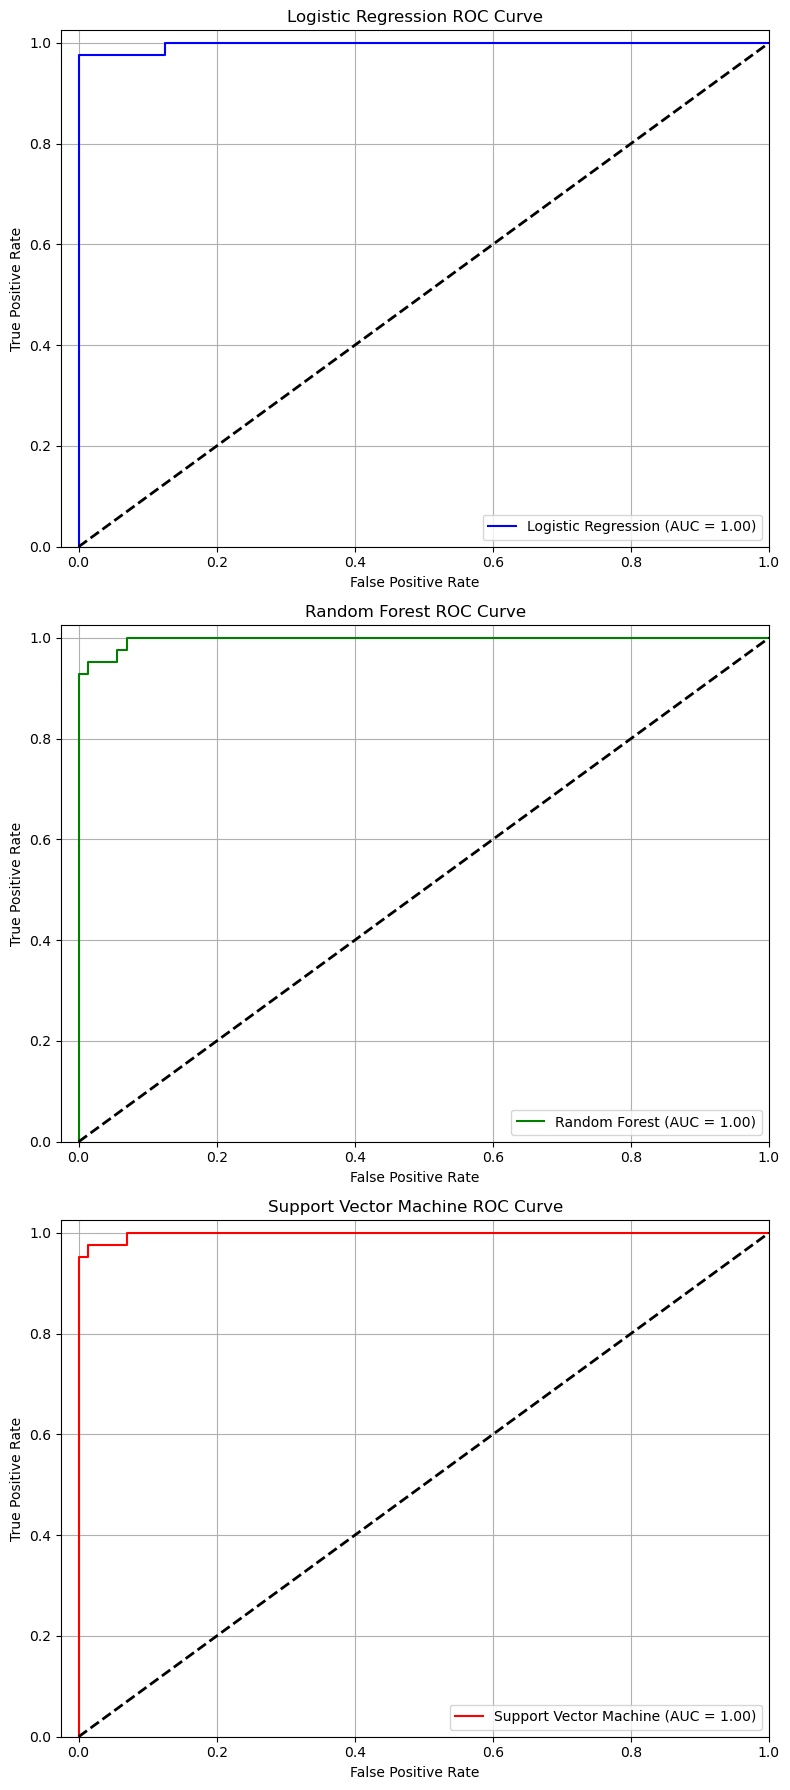

In [13]:
# Calculate ROC curve and AUC for Logistic Regression
y_scores_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_scores_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Calculate ROC curve and AUC for Random Forest
y_scores_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Calculate ROC curve and AUC for Support Vector Machine
y_scores_svm = svm.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_scores_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# Create a figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 18))

# Plot ROC curve for Logistic Regression
ax1.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = {:.2f})'.format(auc_lr), linestyle='-', color='blue')
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_title('Logistic Regression ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_xlim([-0.025, 1.0])
ax1.set_ylim([0.0, 1.025])
ax1.legend(loc="lower right")
ax1.grid()

# Plot ROC curve for Random Forest
ax2.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(auc_rf), linestyle='-', color='green')
ax2.plot([0, 1], [0, 1], 'k--', lw=2)
ax2.set_title('Random Forest ROC Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_xlim([-0.025, 1.0])
ax2.set_ylim([0.0, 1.025])
ax2.legend(loc="lower right")
ax2.grid()

# Plot ROC curve for Support Vector Machine
ax3.plot(fpr_svm, tpr_svm, label='Support Vector Machine (AUC = {:.2f})'.format(auc_svm), linestyle='-', color='red')
ax3.plot([0, 1], [0, 1], 'k--', lw=2)
ax3.set_title('Support Vector Machine ROC Curve')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_xlim([-0.025, 1.0])
ax3.set_ylim([0.0, 1.025])
ax3.legend(loc="lower right")
ax3.grid()

# Adjust spacing between subplots
plt.tight_layout()

# Display the plot
plt.show()